In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#definiamo il potential landscape in questo modo:
def pot_land(x, mu1, v1, v2, v3, mu2):
    pot1=[]
    pot2=[]
    wall = 75
    walls=[]
    delta = 10
    for obj in x:
        if obj < 10:
            pot1.append(mu1)
            pot2.append(mu1)
            walls.append(0)
        if obj == 10:
            pot1.append(wall)
            pot2.append(wall)
            walls.append(wall)
        if obj > 10 and obj < 15:
            pot1.append(v1)
            pot2.append(v1 - delta)
            walls.append(0)
        if obj == 15:
            pot1.append(wall)
            pot2.append(wall)
            walls.append(wall)
        if obj > 15 and obj < 20:
            pot1.append(v2)
            pot2.append(v2 - delta)
            walls.append(0)
        if obj == 20:
            pot1.append(wall)
            pot2.append(wall)
            walls.append(wall)
        if obj > 20 and obj < 25:
            pot1.append(v3)
            pot2.append(v3 - delta)
            walls.append(0)
        if obj == 25:
            pot1.append(wall)
            pot2.append(wall)
            walls.append(wall)
        if obj > 25:
            pot1.append(mu2)
            pot2.append(mu2)
            walls.append(0)

    return np.array([pot1, pot2, walls])

In [3]:
x = np.linspace(0, 35, 1751, endpoint=True)
mu1, v1, v2, v3, mu2 = 50, 64, 47, 53, 55
pot = pot_land(x, mu1, v1, v2, v3, mu2)

In [4]:
#occupations
occ1 = []
for i in range(len(x)):
    if x[i] == 12.5 or x[i] == 17.5 or x[i] == 22.5:
        if pot[0][i] <= mu1:
            occ1.append(pot[0][i])
        else:
            occ1.append(0)
    else:
        occ1.append(0)   
occ2 = []
for i in range(len(x)):
    if x[i] == 12.5 or x[i] == 17.5 or x[i] == 22.5:
        if pot[1][i] <= mu1:
            occ2.append(pot[1][i])
        else:
            occ2.append(0)
    else:
        occ2.append(0)

In [5]:
#lorentian broadening
y = np.linspace(0, 75, 751, endpoint=True)
gamma = 2
def lorentz(x, mu):
    gamma = 2
    return gamma/((x-mu)**2 + gamma**2)
mus = [obj for obj in occ1 + occ2 if obj != 0]

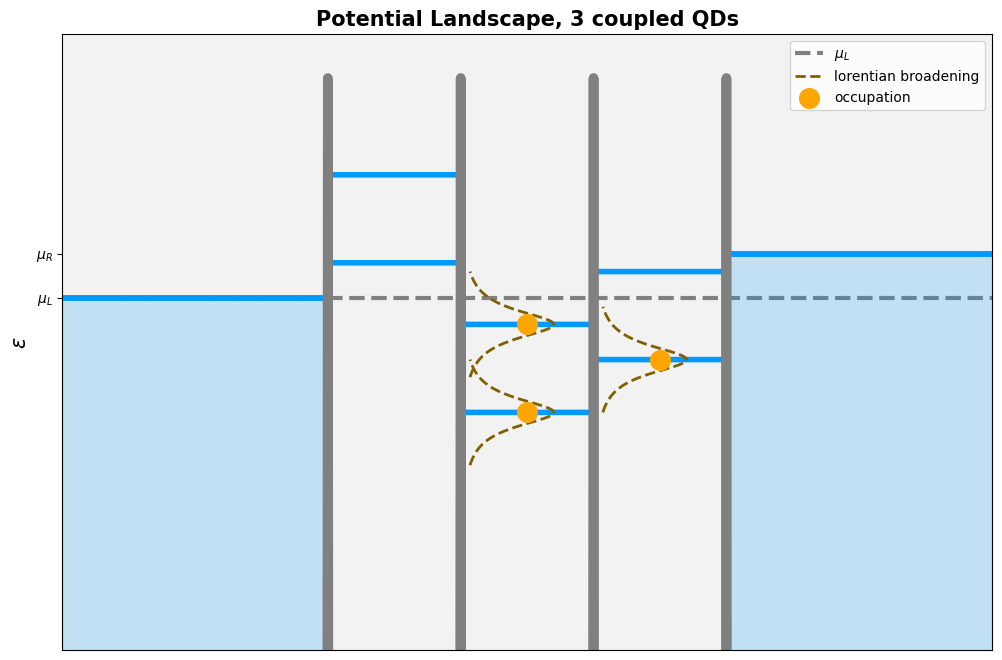

In [6]:
plt.figure(figsize = (12,8))
plt.plot(x, [mu1]*len(x), zorder = 0, lw = 3, ls = '--', label = f"$\\mu_L$", color = 'gray')
#plt.plot(x, [mu2]*len(x), zorder = 0, lw = 3, ls = '--', label = f"$\\mu_R$", color = 'gray')
for i in range(len(mus)):
    shift = [15,15,20]
    newy = np.array([obj for obj in y if mus[i]- 3*gamma <= obj and mus[i]+ 3*gamma>= obj])
    label = ["lorentian broadening"] + [""]*(len(mus)-1)
    plt.plot(lorentz(newy, mus[i])*7 + shift[i], newy, zorder = 4, lw = 2, color = '#806000', label = label[i], ls = 'dashed')
    #plt.fill_betweenx(newy, lorentz(newy, mus[i])*7 + shift, alpha=0.6, color = '#d1b3ff', zorder=3)
plt.plot(x, pot[0], zorder = 1, lw = 4, color = '#0099ff')
plt.plot(x, pot[1], zorder = 1, lw = 4, color = '#0099ff')
plt.plot(x, pot[2], zorder = 2, lw = 7, color = 'gray')
plt.scatter(x, occ1, marker='o', s = 200, color = 'orange', label = "occupation", zorder = 5)
plt.scatter(x, occ2, marker='o', s = 200, color = 'orange', zorder = 5)
plt.title(f"Potential Landscape, 3 coupled QDs", fontweight = 'bold', fontsize=15)
plt.fill_between(x, pot[0], where=(x >= 0) & (x <= 10), alpha=0.2, color = '#0099ff')
plt.fill_between(x, pot[0], where=(x>=25) & (x<=35), alpha=0.2, color = '#0099ff')
plt.xlabel(None)
plt.xticks([])
plt.xlim(0,35)
plt.ylabel(f"$\\epsilon$", fontweight = 'bold', fontsize=15)
plt.yticks([mu1, mu2], [f"$\\mu_L$", f"$\\mu_R$"])
plt.ylim(10, 80)
plt.grid(False)
plt.legend()
plt.gca().set_facecolor('#f2f2f2')
plt.savefig("potential_landscape.png", dpi=150)
plt.show()